# **Kaggle – DataTops®**
Tu TA ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Aspectos importantes
- Última submission:
    - Mañana: 17 de febrero a las 5pm
    - Tarde: 19 de febrero a las 5pm
- **Enlace de la competición**: https://www.kaggle.com/t/c5cc87b50c4b4770bdc8f5acbe15577d
- **Requisito**: Estar registrado en [Kaggle](https://www.kaggle.com/)

## Métrica:
El error cuadrático medio (RMSE, por sus siglas en inglés) es una medida de la desviación estándar de los residuos (errores de predicción). Los residuos representan la diferencia entre los valores observados y los valores predichos por el modelo. El RMSE indica qué tan dispersos están estos errores: cuanto menor es el RMSE, más cercanas están las predicciones a los valores reales. En otras palabras, el RMSE mide qué tan bien se ajusta la línea de regresión a los datos.


$$ RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^{n}{\Big(\frac{d_i -f_i}{\sigma_i}\Big)^2}}$$


## 1. Librerías

In [121]:
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split,  cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
import urllib.request
import seaborn as sns
import matplotlib.pyplot as plt
import toolbox_ML_v2 as tl
import re
import bootcampviztools as bt

from transformer import (
    transformer_screenresolution,
    transformer_cpu,
    transformer_memory,
    transformer_gpu,
    transformer_weight,
    transformer_ram,)

## 2. Datos

In [93]:
# Para que funcione necesitas bajarte los archivos de datos de Kaggle
df = pd.read_csv("./data/train.csv", index_col = 'laptop_ID')

### 2.1 Exploración de los datos

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 755 to 229
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           912 non-null    object 
 1   Product           912 non-null    object 
 2   TypeName          912 non-null    object 
 3   Inches            912 non-null    float64
 4   ScreenResolution  912 non-null    object 
 5   Cpu               912 non-null    object 
 6   Ram               912 non-null    object 
 7   Memory            912 non-null    object 
 8   Gpu               912 non-null    object 
 9   OpSys             912 non-null    object 
 10  Weight            912 non-null    object 
 11  Price_in_euros    912 non-null    float64
dtypes: float64(2), object(10)
memory usage: 92.6+ KB


In [95]:
# df.head()

In [96]:
# df.tail()

In [97]:
# df.describe()

| Columna          | Qué significa                                                                |
| ---------------- | ---------------------------------------------------------------------------- |
| Company          | Marca (Dell, HP, Apple, Lenovo, etc.)                                        |
| Product          | Nombre/modelo comercial (ej. “XPS 13”, “MacBook Pro”)                        |
| TypeName         | Tipo/form factor (Ultrabook, Gaming, Notebook, Workstation, 2-in-1)          |
| Inches           | Tamaño de pantalla en pulgadas                                               |
| ScreenResolution | Resolución y tipo de panel (ej. “1920x1080”, “IPS”, “Touchscreen”, “4K”)     |
| Cpu              | Procesador (marca + línea + modelo + frecuencia; ej. “Intel Core i7 2.7GHz”) |
| Ram              | Memoria RAM (ej. “8GB”)                                                      |
| Memory           | Almacenamiento (ej. “256GB SSD”, “1TB HDD”, “128GB SSD + 1TB HDD”)           |
| Gpu              | Placa gráfica (ej. “Nvidia GeForce GTX 1050”, “Intel HD Graphics”)           |
| OpSys            | Sistema operativo (Windows, macOS, Linux, No OS)                             |
| Weight           | Peso (ej. “1.37kg”)                                                          |


### 2.3 Definir X e y

In [98]:
X = df.drop(['Price_in_euros'], axis=1)
y = df['Price_in_euros'].copy()
X.shape

(912, 11)

In [99]:
y.shape

(912,)

### 2.4 Dividir X_train, X_test, y_train, y_test

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [101]:
X_train.shape

(729, 11)

In [102]:
X_test.shape

(183, 11)

In [103]:
y_train.shape

(729,)

## 3. Procesado de datos

Nuestro target es la columna `Price_in_euros`

In [104]:
target = 'Price_in_euros'

In [16]:
# X_train.tail()

In [23]:
# for col in X_train.columns:
#     print(f'{col}: {X_train[col].nunique()}=')
#     print(X_train[col].value_counts())
#     print('\n')

#### Tratamiento de columnas Company, TypeName y OpSys (One-Hot Encoding)

In [106]:
one_hot = ['Company','TypeName','OpSys']

In [25]:
# for col in one_hot:
#     X_train = pd.get_dummies(X_train, columns=[col], dtype= int)
#     X_test = pd.get_dummies(X_test, columns=[col], dtype= int)

In [26]:
# X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
# X_test = X_test[X_train.columns]

In [28]:
# print(X_train.shape)
# print(X_test.shape)

#### Tratamiento columna ScreenResolution

In [105]:
screen_tr = transformer_screenresolution(X_train)
screen_ts = transformer_screenresolution(X_test)
screen_tr.shape

(729, 3)

#### Tratamiento columna Gpu

In [107]:
gpu_unicos  = X_train['Gpu'].unique()

In [108]:
gpu_tr = transformer_gpu(X_train)
gpu_ts = transformer_gpu(X_test)
gpu_ts.shape

(183, 20)

#### Tratamiento columna Cpu

In [21]:
cpu_unicos  = X_train['Cpu'].unique()

In [123]:
cpu_tr = transformer_cpu(X_train)
cpu_ts = transformer_cpu(X_test)
cpu_ts.shape

#### Tratamiento columna Memory

In [111]:
unicos  = X_train['Memory'].unique()

In [112]:
memory_tr = transformer_memory(X_train)
memory_ts = transformer_memory(X_test)
memory_ts.shape

(183, 4)

#### Tratamiento columnas Ram y Weight

In [113]:
X_train['Ram_GB'] = X_train['Ram'].str.replace('GB','').astype(int)
X_test['Ram_GB'] = X_test['Ram'].str.replace('GB','').astype(int)

In [114]:
X_train['Weight_kg'] = X_train['Weight'].str.replace('kg','').astype(float)
X_test['Weight_kg'] = X_test['Weight'].str.replace('kg','').astype(float)

In [46]:
# X_train.info()

In [29]:
# print(X_train.shape)
# print(X_test.shape)

### Mini EDA

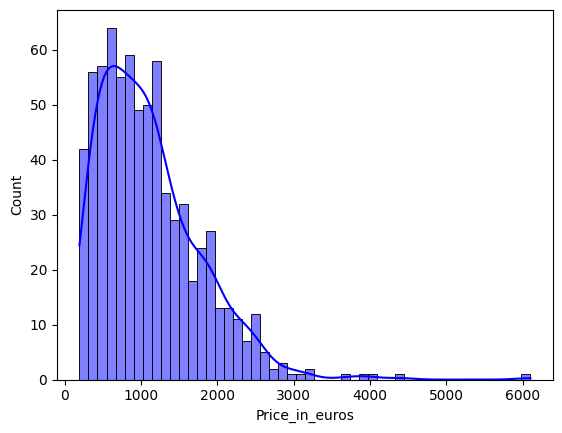

In [30]:
sns.histplot(y_train, color='Blue', kde = True,bins=50)
plt.show()

In [115]:
drop = [ 'Product', 'ScreenResolution', 'Cpu','Ram', 'Memory', 'Gpu', 'Weight']

In [116]:
X_train_final= X_train.copy()
X_test_final = X_test.copy()

In [117]:
X_train = X_train.drop(columns = drop)
X_test = X_test.drop(columns = drop)

In [118]:
X_train_final = pd.concat([X_train, screen_tr , gpu_tr, cpu_tr,memory_tr], axis=1)
X_test_final = pd.concat([X_test, screen_ts , gpu_ts, cpu_ts, memory_ts], axis=1)

print(X_train_final.shape)
print(X_test_final.shape)

(729, 46)
(183, 46)


In [120]:
# X_train_final.columns

In [52]:
# tl.describe_df(X_train_final)

In [53]:
# tl.tipifica_variables(X_train_final)

In [54]:
binaria = tl.tipifica_variables(X_train_final)['Categorica_Binaria']
categorica = tl.tipifica_variables(X_train_final)['Categorica_Nominal']
num_discreta = tl.tipifica_variables(X_train_final)['Numerica_Discreta']
num_continua = tl.tipifica_variables(X_train_final)['Numerica_Continua']

In [35]:
print(X_train.shape)
print(y_train.shape)

(729, 6)
(729,)


In [56]:
numericas = num_continua + num_discreta + categorica

In [1]:
# X_train_final[categorica].hist( bins=20, figsize=(18, 30));

In [2]:
# X_train_final[numericas].hist(bins=20, figsize=(18, 30));

In [59]:
dataset = X_train_final.copy()
dataset['Price_in_euros'] = y_train
dataset_test = X_test_final.copy()
dataset_test['Price_in_euros'] = y_test

In [ ]:
 bt.plot_categorical_relationship_fin(dataset, dataset['Price_in_euros'], 'Inches', relative_freq= True, show_values= True)

##### Si saco los outlie

In [60]:
out_target = dataset['Price_in_euros']> 4000
# sns.histplot(dataset[~out_target]['Price_in_euros'], color='Blue', kde = True,bins=50)
# plt.show()
dataset = dataset[~out_target]
X_train_2 = dataset.drop(columns= 'Price_in_euros')
y_train_2 = dataset['Price_in_euros']

In [61]:
print(dataset.shape)
print(X_train_2.shape)
print(y_train_2.shape)

(727, 90)
(727, 89)
(727,)


In [62]:
out_target = dataset_test['Price_in_euros'] > 4000
dataset_test = dataset_test[~out_target]
X_test_2 = dataset_test.drop(columns= 'Price_in_euros')
y_test_2 = dataset_test['Price_in_euros']

In [63]:
# for col in binaria:
#     bt.plot_grouped_histograms(dataset,col, target, group_size =2)

#### Estacalado para modelos que lo necesiten 

In [64]:
X_train_sc = X_train_final.copy()
X_test_sc  = X_test_final .copy()

scaler = StandardScaler()
X_train_sc[numericas] = scaler.fit_transform(X_train_sc[numericas])
X_test_sc[numericas] = scaler.transform(X_test_sc[numericas])

-----------------------------------------------------------------------------------------------------------------

## 4. Modelado

### 4.1 Baseline de modelos


In [65]:
# X_train = X_train[features_num]
# X_test = X_test[features_num]

In [66]:
rf_reg = RandomForestRegressor(max_depth=5, random_state = 42)

In [67]:
rf_reg.fit(X_train_final,y_train)

RandomForestRegressor(max_depth=5, random_state=42)

### 4.2 Sacar métricas, valorar los modelos

Recuerda que en la competición se va a evaluar con la métrica de ``RMSE``.

In [68]:
y_pred = rf_reg.predict(X_test_final)

In [69]:
root_mean_squared_error(y_test,y_pred)

np.float64(356.542094043227)

### 4.3 Optimización (up to you 🫰🏻)

In [52]:
X_train_final['Inches'] = df['Inches']

In [53]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols

['Company', 'TypeName', 'OpSys']

In [54]:
from catboost import CatBoostRegressor
cat_reg = CatBoostRegressor(depth=5, random_state= 42, verbose = False, loss_function="RMSE")
cat_reg.fit(X_train_final, y_train,cat_features = cat_cols)

In [55]:
y_pred = cat_reg.predict(X_test_final)
root_mean_squared_error(y_test,y_pred)

np.float64(249.40338528134876)

In [56]:
np.sqrt(-np.mean(cross_val_score(cat_reg, X_train_final, y_train, cv = 5, scoring = "neg_mean_squared_error",fit_params={"cat_features": cat_cols})))

C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(


np.float64(255.99670004462666)

### Ajuste de hiperparametros

In [92]:
X_full = pd.concat([X_train_final, X_test_final], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)

#### Ajuste 1

In [57]:
from sklearn.model_selection import GridSearchCV

cb = CatBoostRegressor(loss_function="RMSE", random_seed=42, verbose=0)

param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "iterations": [500, 1000],
    "l2_leaf_reg": [1, 3, 5, 7],           
    "rsm": [0.8, 1.0]                    
}

grid = GridSearchCV(
    estimator=cb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train_final, y_train,cat_features = cat_cols)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE (CV):", -grid.best_score_)

best_model = grid.best_estimator_

Mejores hiperparámetros: {'depth': 4, 'iterations': 1000, 'l2_leaf_reg': 3, 'learning_rate': 0.1, 'rsm': 0.8}
Mejor RMSE (CV): 246.54901547634017


In [58]:
y_pred = best_model.predict(X_test_final)
root_mean_squared_error(y_test,y_pred)

np.float64(252.95718282633294)

In [61]:
np.sqrt(-np.mean(cross_val_score(best_model, X_train_final, y_train, cv = 5, scoring = "neg_mean_squared_error",fit_params={"cat_features": cat_cols})))

C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(


np.float64(250.65671117995413)

#### Ajuste 2

In [62]:
cb = CatBoostRegressor(loss_function="RMSE", random_seed=42, verbose=0, depth =  4, iterations = 500,
                       learning_rate= 0.1)

param_grid = {
    "l2_leaf_reg": [1, 3, 5, 10],
    "min_data_in_leaf": [5, 20, 50],
    "rsm": [0.6, 0.8, 1.0],
    "random_strength": [0, 1, 2, 5],
}

grid_2 = GridSearchCV(
    estimator= cb,
    param_grid= param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid_2.fit(X_train_final, y_train,cat_features = cat_cols)

print("Mejores hiperparámetros:", grid_2.best_params_)
print("Mejor RMSE (CV):", -grid_2.best_score_)

best_model_2 = grid_2.best_estimator_

C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mejores hiperparámetros: {'l2_leaf_reg': 3, 'min_data_in_leaf': 5, 'random_strength': 2, 'rsm': 0.8}
Mejor RMSE (CV): 246.16695556049544


In [63]:
y_pred = best_model_2.predict(X_test_final)
root_mean_squared_error(y_test,y_pred)

np.float64(248.06097133945096)

In [64]:
np.sqrt(-np.mean(cross_val_score(best_model_2, X_train_final, y_train, cv = 5, scoring = "neg_mean_squared_error",fit_params={"cat_features": cat_cols})))

C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(


np.float64(250.65671117995413)

#### Ajuste 3 - Lo subi 14 -279.9022

In [65]:
cb = CatBoostRegressor(loss_function="RMSE", random_seed=42, verbose=0, depth =  4, iterations = 750,
                       learning_rate= 0.1,
                      l2_leaf_reg= 1, min_data_in_leaf= 5, rsm= 0.8)
param_grid = {
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "random_strength": [0, 1, 2, 5,10,15],
    "leaf_estimation_iterations": [1, 3, 5, 10],
    "border_count": [32, 64, 128, 254]
}

grid = GridSearchCV(
    estimator= cb,
    param_grid= param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
    
)

grid.fit(X_train_final, y_train,cat_features = cat_cols)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE (CV):", -grid.best_score_)

best_model_3 = grid.best_estimator_

Mejores hiperparámetros: {'border_count': 64, 'leaf_estimation_iterations': 1, 'random_strength': 2, 'subsample': 0.7}
Mejor RMSE (CV): 241.2262248696996


In [66]:
y_pred = best_model_3.predict(X_test_final)
root_mean_squared_error(y_test,y_pred)

np.float64(254.39903175796198)

In [67]:
np.sqrt(-np.mean(cross_val_score(best_model_3, X_train_final, y_train, cv = 5, scoring = "neg_mean_squared_error",fit_params={"cat_features": cat_cols})))

C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(


np.float64(244.36281534935193)

In [ ]:
best_model_3.fit()

##### Entreno con X_full e y_full

-----------------------------------------------------------------

## Una vez listo el modelo, toca predecir ``test.csv``

**RECUERDA: APLICAR LAS TRANSFORMACIONES QUE HAYAS REALIZADO EN `train.csv` a `test.csv`.**


Véase:
- Estandarización/Normalización
- Eliminación de Outliers
- Eliminación de columnas
- Creación de columnas nuevas
- Gestión de valores nulos
- Y un largo etcétera de técnicas que como Data Scientist hayas considerado las mejores para tu dataset.

## 1. Carga los datos de `test.csv` para predecir.


In [73]:
X_pred = pd.read_csv("./data/test.csv", index_col = 'laptop_ID')
# X_pred.head()

In [78]:
screen_pr = transformer_screenresolution(X_pred)
cpu_pr = transformer_cpu(X_pred)
memory_pr = transformer_memory(X_pred)
gpu_pr = transformer_gpu(X_pred)

In [79]:
X_pred['Ram_GB'] = X_pred['Ram'].str.replace('GB','').astype(int)
X_pred['Weight_kg'] = X_pred['Weight'].str.replace('kg','').astype(float)

In [80]:
drop = [ 'Product', 'ScreenResolution', 'Cpu','Ram', 'Memory', 'Gpu', 'Weight']
X_pred_final = X_pred.copy()
X_pred_final = X_pred.drop(columns = drop)

In [81]:
X_pred_final = pd.concat([X_pred_final, screen_pr , gpu_pr, cpu_pr,memory_pr], axis=1)
X_pred_final .shape

(391, 46)

 ## 2. Replicar el procesado para ``test.csv``

In [117]:
# X_pred_final

In [82]:
predictions_submit = best_model_3.predict(X_pred_final)
predictions_submit

array([1734.86159878,  288.10199397,  348.8645249 , 1002.60366939,
        956.66837138,  450.86790133,  833.027326  ,  907.50646129,
       1235.05671054,  288.43385273, 2015.82514834, 1388.5502385 ,
        518.9108615 , 1506.25888503,  766.67694875,  796.00566475,
       2485.13463428, 1279.43667624, 1986.47678328,  681.96131139,
       1566.24406505,  257.44126049,  804.56736511, 1218.73250464,
        363.45154579,  745.21724347,  595.45875345, 1022.45798744,
       3397.49957569, 1087.22893245, 2388.09634967,  419.85847575,
        768.1161966 , 2708.80510687, 1979.72466492, 1605.23172768,
        585.59313689, 1376.17925492,  906.72218082, 1604.38682565,
        657.65037838,  732.40032918,  507.9251877 , 1349.74151333,
       1133.23872997, 1055.75500599,  997.97570809,  496.35358168,
        637.43675607,  430.80623843, 1784.97225553,  802.1209819 ,
       1124.95352583,  366.16565763, 1839.75950098, 1680.2448497 ,
        813.09122273,  948.05892862,  881.37695556,  570.23034

**¡OJO! ¿Por qué me da error?**

IMPORTANTE:

- SI EL ARRAY CON EL QUE HICISTEIS `.fit()` ERA DE 4 COLUMNAS, PARA `.predict()` DEBEN SER LAS MISMAS
- SI AL ARRAY CON EL QUE HICISTEIS `.fit()` LO NORMALIZASTEIS, PARA `.predict()` DEBÉIS NORMALIZARLO
- TODO IGUAL SALVO **BORRAR FILAS**, EL NÚMERO DE ROWS SE DEBE MANTENER EN ESTE SET, PUES LA PREDICCIÓN DEBE TENER **391 FILAS**, SI O SI

**Entonces, si al cargar los datos de ``train.csv`` usaste `index_col=0`, ¿tendré que hacer lo también para el `test.csv`?**

In [94]:
# ¿Qué opináis?
# ¿Sí, no?

![wow.jpeg](attachment:wow.jpeg)

## 3. **¿Qué es lo que subirás a Kaggle?**

**Para subir a Kaggle la predicción esta tendrá que tener una forma específica.**

En este caso, la **MISMA** forma que `sample_submission.csv`.

In [83]:
sample = pd.read_csv("data/sample_submission.csv")

In [84]:
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


In [85]:
sample.shape

(391, 2)

## 4. Mete tus predicciones en un dataframe llamado ``submission``.

In [86]:
#¿Cómo creamos la submission?
submission = pd.DataFrame({
    'laptop_ID': X_pred.index,
    'Price_in_euros' : predictions_submit
})

In [87]:
submission.head()

,laptop_ID,Price_in_euros
0,209,1734.861599
1,1281,288.101994
2,1168,348.864525
3,1231,1002.603669
4,1020,956.668371


In [88]:
submission.shape

(391, 2)

## 5. Pásale el CHEQUEADOR para comprobar que efectivamente está listo para subir a Kaggle.

In [89]:
def chequeador(df_to_submit):
    """
    Esta función se asegura de que tu submission tenga la forma requerida por Kaggle.

    Si es así, se guardará el dataframe en un `csv` y estará listo para subir a Kaggle.

    Si no, LEE EL MENSAJE Y HAZLE CASO.

    Si aún no:
    - apaga tu ordenador,
    - date una vuelta,
    - enciendelo otra vez,
    - abre este notebook y
    - leelo todo de nuevo.
    Todos nos merecemos una segunda oportunidad. También tú.
    """
    if df_to_submit.shape == sample.shape:
        if df_to_submit.columns.all() == sample.columns.all():
            if df_to_submit.laptop_ID.all() == sample.laptop_ID.all():
                print("You're ready to submit!")
                df_to_submit.to_csv("submission_14.csv", index = False) #muy importante el index = False
                urllib.request.urlretrieve("https://www.mihaileric.com/static/evaluation-meme-e0a350f278a36346e6d46b139b1d0da0-ed51e.jpg", "gfg.png")
                img = Image.open("gfg.png")
                img.show()
            else:
                print("Check the ids and try again")
        else:
            print("Check the names of the columns and try again")
    else:
        print("Check the number of rows and/or columns and try again")
        print("\nMensaje secreto del TA: No me puedo creer que después de todo este notebook hayas hecho algún cambio en las filas de `test.csv`. Lloro.")

In [90]:
chequeador(submission)

You're ready to submit!
